### Import Library

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import folium

### Load Dataset

In [57]:
df = pd.read_csv('../data/us_accidents.csv', sep=',')
df.head()

,ID,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Temperature(F),Humidity(%),Visibility(mi),Weather_Condition
0,A-0,2020-01-01 00:00:00,2020-01-01 00:30:00,33.988963,-84.204782,29.443190,-94.412338,50.936455,84.476703,6.890678,Cloudy
1,A-1,2020-01-01 01:00:00,2020-01-01 01:30:00,47.817143,-93.442507,38.005623,-96.686633,49.758304,78.807502,8.068473,Cloudy
2,A-2,2020-01-01 02:00:00,2020-01-01 02:30:00,42.567855,-106.356926,45.950700,-122.538402,102.500366,61.617606,2.879445,Fog
3,A-3,2020-01-01 03:00:00,2020-01-01 03:30:00,39.367804,-77.613684,42.573397,-104.548874,49.963696,96.044243,6.436304,Clear
4,A-4,2020-01-01 04:00:00,2020-01-01 04:30:00,28.744447,-84.970323,44.357468,-102.328850,51.755978,28.042706,5.931587,Fog


In [58]:
# Melihat Informasi data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 500 non-null    object 
 1   Start_Time         500 non-null    object 
 2   End_Time           500 non-null    object 
 3   Start_Lat          500 non-null    float64
 4   Start_Lng          500 non-null    float64
 5   End_Lat            500 non-null    float64
 6   End_Lng            500 non-null    float64
 7   Temperature(F)     500 non-null    float64
 8   Humidity(%)        500 non-null    float64
 9   Visibility(mi)     500 non-null    float64
 10  Weather_Condition  500 non-null    object 
dtypes: float64(7), object(4)
memory usage: 43.1+ KB


### Data Preprocessing

In [59]:
# Menghapus baris dengan nilai NaN pada kolom 'Start_Lat' dan 'Start_Lng'
df = df.dropna(subset=['Start_Lat', 'Start_Lng'])

In [60]:
# Memastikan type data kolom Start_Lat dan Start_Lng float64
df['Start_Lat'] = df['Start_Lat'].astype(float)
df['Start_Lng'] = df['Start_Lng'].astype(float)

In [61]:
# Konversi Koordinat ke Radian (Untuk Haversine Distance)
coords = np.radians(df[['Start_Lat', 'Start_Lng']])

### Atur Parameter Dbscan

In [62]:
# eps = radius cluster dalam kilometer (misalnya 1 km)
kms = 1.0
eps_value = kms / 6371.0   # 6371 = radius bumi dalam km

db = DBSCAN(
    eps=eps_value,
    min_samples=10,       # minimal titik dalam radius eps
    metric='haversine'    # jarak GPS akurat
)

### Pemodelan Clustering

In [63]:
# Fitting DBSCAN dan mendapatkan label cluster
clusters = db.fit_predict(coords)
df['cluster'] = clusters

print("Jumlah titik tiap cluster:")
print(df['cluster'].value_counts())

Jumlah titik tiap cluster:
cluster
-1    500
Name: count, dtype: int64


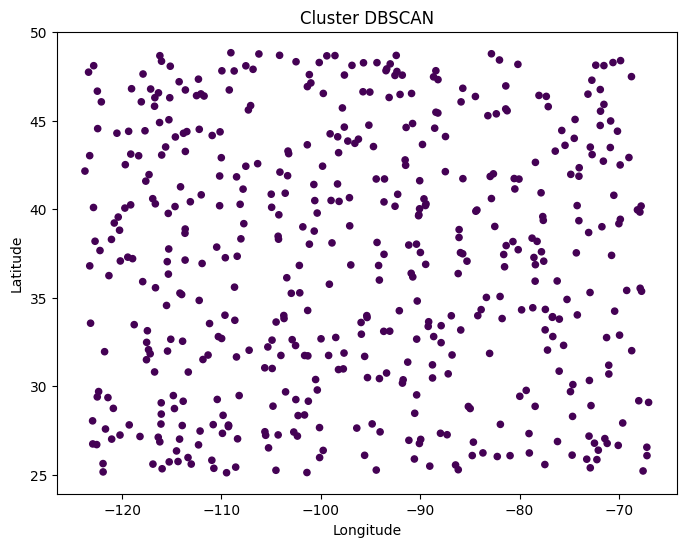

In [64]:
plt.figure(figsize=(8,6))
plt.scatter(df['Start_Lng'], df['Start_Lat'], c=df['cluster'], cmap='viridis', s=20)
plt.title("Cluster DBSCAN")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### Pembuatan Peta dengan Folium

In [65]:
# posisikan peta ke tengah data
center_lat = df['Start_Lat'].median()
center_lng = df['Start_Lng'].median()

m = folium.Map(location=[center_lat, center_lng], zoom_start=5)

In [66]:
# Menambahkan titik ke peta dengan warna berdasarkan cluster
colors = [
    "red", "blue", "green", "purple", "orange", "darkred", "lightred",
    "beige", "darkblue", "darkgreen", "cadetblue", "darkpurple",
    "white", "pink", "lightblue", "lightgreen", "gray", "black"
]

for _, row in df.iterrows():
    cluster_id = row["cluster"]
    color = "gray" if cluster_id == -1 else colors[cluster_id % len(colors)]

    folium.CircleMarker(
        location=[row["Start_Lat"], row["Start_Lng"]],
        radius=4,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=f"Cluster: {cluster_id}"
    ).add_to(m)

In [67]:
# Menyimpan File Peta ke HTML
m.save("dbscan_map.html")
print("Peta berhasil dibuat → file: cluster_map.html")

Peta berhasil dibuat → file: cluster_map.html
